# DATA-445 In-Class Assignment 1

Consider the `Real_Estate.csv` data file posted on Blackboard (under the In-Class 1 assignment link). This file contains information related to 414 houses. The goal is to predict the house price of unit area.

## 1. (3 points) Using the pandas library, read the csv data file and create a data-frame called `house_price`.

In [5]:
import pandas as pd

house_price = pd.read_csv('Real_Estate.csv')
house_price.head()

,No,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,1,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,3,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,4,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,5,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 2. (3 points) Drop the `No` column.

In [6]:
#dropping the No column since it is not useful for our analysis
house_price = house_price.drop(columns=['No'], axis=1)
house_price.head()

,transaction_date,house_age,distance_to_the_nearest_MRT_station,number_of_convenience_stores,latitude,longitude,house_price_of_unit_area
0,2012.917,32.0,84.87882,10,24.98298,121.54024,37.9
1,2012.917,19.5,306.59470,9,24.98034,121.53951,42.2
2,2013.583,13.3,561.98450,5,24.98746,121.54391,47.3
3,2013.500,13.3,561.98450,5,24.98746,121.54391,54.8
4,2012.833,5.0,390.56840,5,24.97937,121.54245,43.1


## 3. (4 points) Create a histogram of `house_age`. Describe the plot.

<Axes: >

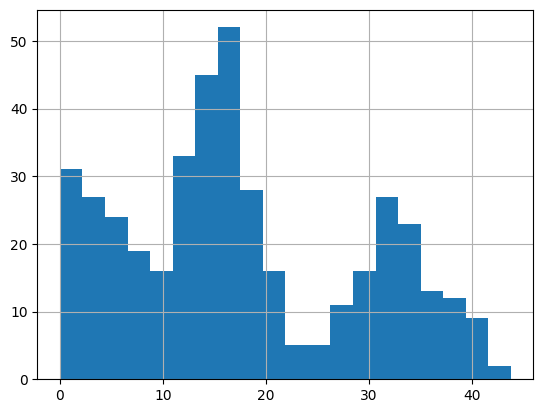

In [11]:
#creating the histogram of house_age
house_price["house_age"].hist(bins=20)

From the above histogram we can see that there are three peaks, which indicates that there are three groups of houses.(new houses,medium-age houses, old houses)

## 4. (4 points) Create a histogram of `distance_to_the_nearest_MRT_station`. Describe the plot.

<Axes: >

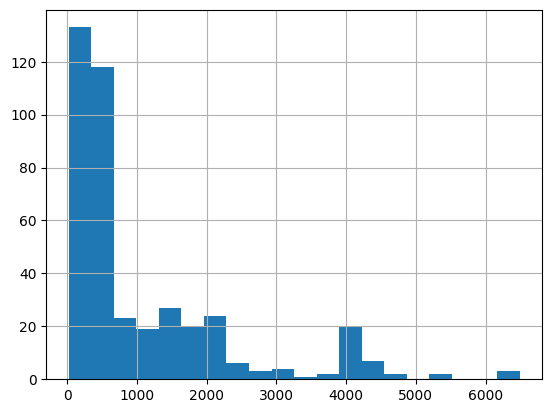

In [6]:
#Creating the histogram of distance to the nearest MRT station
house_price["distance_to_the_nearest_MRT_station"].hist(bins=20)

In this histogram above we can tell that there is a lot of MRT stations nearby because there is a large peak near the 0-1000 marker the amount skews left so there is a drop off in amount of stations as you get further away leading me to beleive that this is from a major city where this type of transportation is necessary.

## 5. (5 points) Build a linear regression model

Input variables: `house_age`, `distance_to_the_nearest_MRT_station`, `number_of_convenience_stores`, `latitude`, and `longitude`.

Target variable: `house_price_of_unit_area`.

In [ ]:
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# setting the input variables
X = house_price [[
    "house_age",
    "distance_to_the_nearest_MRT_station",
    "number_of_convenience_stores",
    "latitude",
    "longitude"
]]

Y = house_price[["house_price_of_unit_area"]]

# splitting the data into train (50%) and validation (50%)
X_train, X_val, Y_train, Y_val = train_test_split(
    X,
    Y,
    test_size=0.5,
    shuffle=True,
    random_state=42
)
# importing linear regression 
from sklearn.linear_model import LinearRegression

# fitting the linear regression model on training data
lm_md = LinearRegression().fit(X_train, Y_train)

# predicting on validation set
val_preds = lm_md.predict(X_val)

# comparing predictions and actuals using MSE
mse = np.mean((Y_val - val_preds) ** 2)

print( mse)

66.8885329753648


## 6. (3 points) Using the model from part 5, predict the house price of unit area

For a house with: `house_age = 5`, `distance_to_the_nearest_MRT_station = 500`, `number_of_convenience_stores = 3`, `latitude = 24.98`, and `longitude = 121.49`.

In [ ]:
#values for the house we want to predict
new_house_price_for_unit_area = pd.DataFrame({
    "house_age": [5],
    "distance_to_the_nearest_MRT_station": [500],
    "number_of_convenience_stores": [3],
    "latitude": [24.98],
    "longitude": [121.49]
})

# Predict the house price
prediction = lm_md.predict(new_house_price_for_unit_area)

print(prediction[0])

# I believe that the house price of the unit area will be 48.16 of whatever unit this may be I assume this will be 
# for the price per square meter and when we square rt that that wil be the aproximate price in thousands.

[48.16526834]
